# Convex Functions: Epigraphs, Level Sets, and First-Order Characterizations

This notebook explores the visual geometry of convex functions in one and two dimensions. We plot epigraphs to verify convexity, examine level sets (contour plots) of multivariate convex functions, and illustrate the **first-order condition** -- the fact that a tangent line (or tangent hyperplane) always lies below a convex function.

**Learning objectives.** After working through this notebook you should be able to:
1. Recognize convexity from the shape of an epigraph.
2. Relate sublevel sets to convexity.
3. Explain why the first-order Taylor approximation is a global under-estimator for convex functions.

## Definition of Convexity

A function $f: \mathbb{R}^n \to \mathbb{R}$ is **convex** if, for all $x, y$ in its domain and all $\lambda \in [0,1]$,

$$
f(\lambda x + (1-\lambda) y) \leq \lambda f(x) + (1-\lambda) f(y).
$$

Geometrically, this means the line segment joining any two points on the graph of $f$ lies on or above the graph. An equivalent geometric characterization is that the **epigraph**

$$
\operatorname{epi}(f) = \{(x, t) : t \geq f(x)\}
$$

is a convex set. In the plots below, the shaded region is the epigraph; if it is a convex set, the function is convex.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
kwargs = {'linewidth' : 2.5}
font = {'weight' : 'normal',
        'size'   : 16}
matplotlib.rc('font', **font)

## Epigraphs of Univariate Convex Functions

We plot several common univariate functions and shade their epigraphs. Observe that in every case the shaded region is a convex set, confirming convexity.

- $e^{-10x}$ is convex because the exponential of a linear function is convex.
- $-\log(x)$ is convex on $x > 0$ (its second derivative is $1/x^2 > 0$).
- $x^2$ is the prototypical convex function.
- $-x^{0.3}$ is convex on $x > 0$ (since $x^p$ with $0 < p < 1$ is concave, its negation is convex).
- $x^{-3}$ is convex on $x > 0$ (power functions $x^p$ with $p < 0$ or $p \geq 1$ are convex on $\mathbb{R}_{++}$).
- $|x|^{1.2}$ is convex (power of a norm with exponent $\geq 1$).

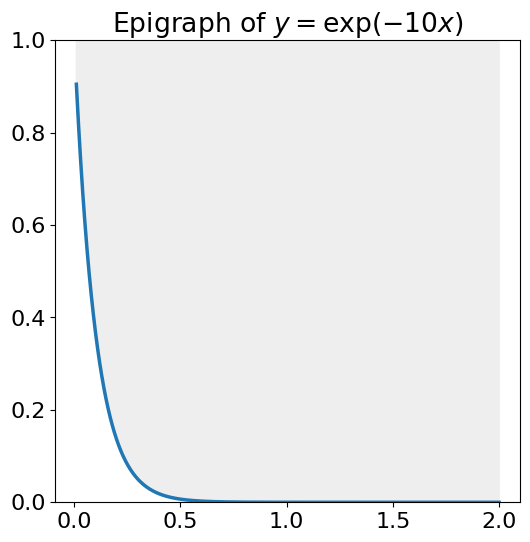

In [2]:


xs = np.linspace(0.01, 2, 1000)
ys = np.exp(-10 * xs)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of $y=\exp(-10x)$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 1)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')





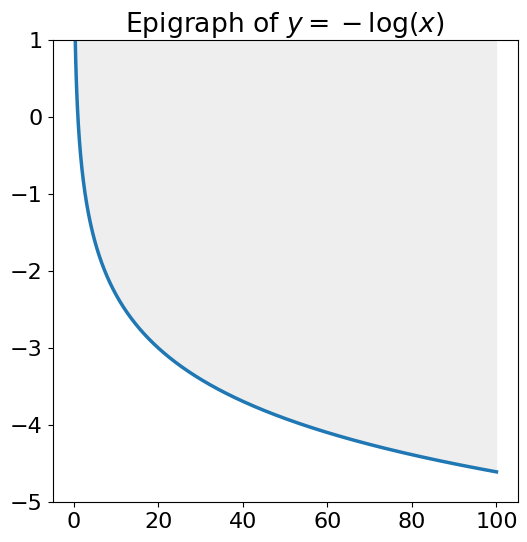

In [3]:
xs = np.linspace(0.01, 100, 10000)
ys = - np.log(xs)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of $y=-\log(x)$')
plt.plot(xs, ys, **kwargs)
plt.ylim(-5, 1)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')

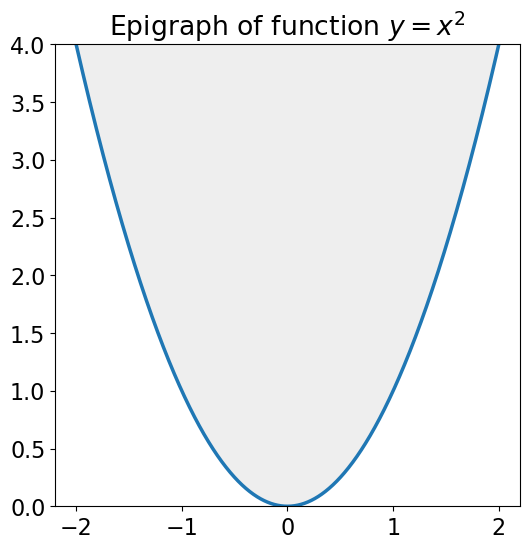

In [11]:
xs = np.linspace(-2, 2, 1000)
ys = xs**2
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  x^2$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 4)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')
# plt.savefig('epigraph.pdf')

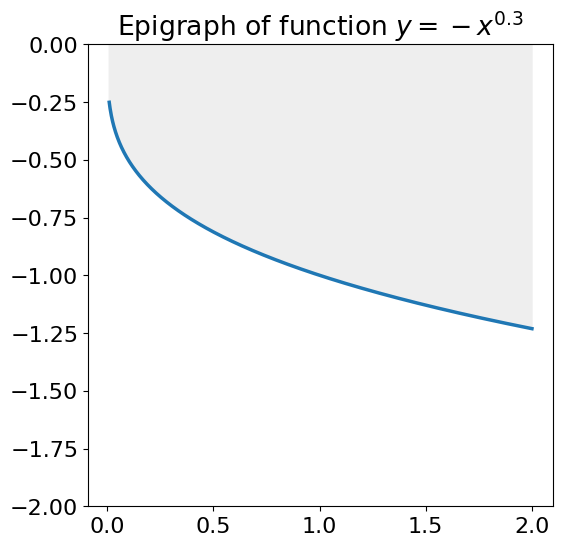

In [4]:
xs = np.linspace(0.01, 2, 1000)
ys = - np.power(xs, 0.3)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  - x^{0.3}$')
plt.plot(xs, ys, **kwargs)
plt.ylim(-2, 0)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')
 

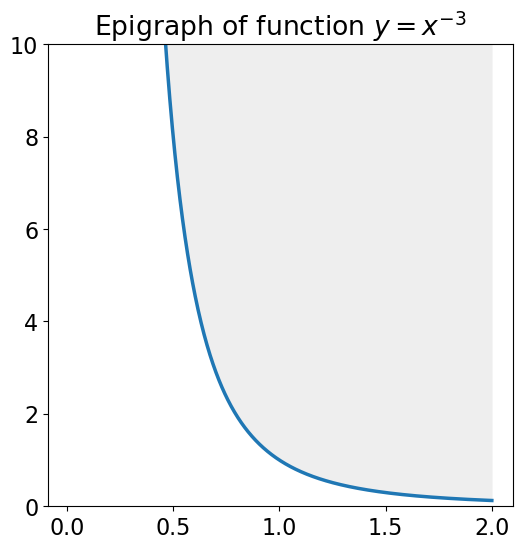

In [27]:
xs = np.linspace(0.01, 2, 1000)
ys = np.power(xs, -3)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  x^{-3}$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 10)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')

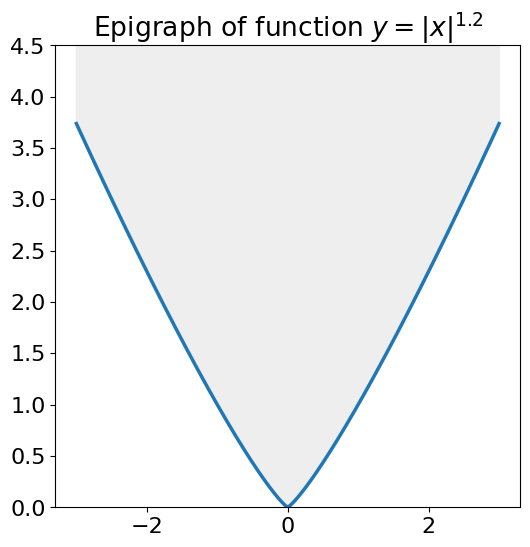

In [5]:
xs = np.linspace(-3, 3, 1000)
ys = np.power(np.abs(xs), 1.2)
plt.figure(1, figsize=(6, 6))
plt.title('Epigraph of function $y =  |x|^{1.2}$')
plt.plot(xs, ys, **kwargs)
plt.ylim(0, 4.5)
plt.fill_between(xs, ys+10, ys, color='#eeeeee')

## Level Sets (Contour Plots) of Convex Functions

The **$\alpha$-sublevel set** of a function $f$ is $\{x : f(x) \leq \alpha\}$. A key property is that all sublevel sets of a convex function are convex sets (though the converse is not true in general).

Contour plots display level sets $\{x : f(x) = \alpha\}$. For convex functions in $\mathbb{R}^2$, these contours are nested convex curves. Below we visualize level sets for several bivariate convex functions including exponential quadratics, general quadratics, and the $\ell_1$-norm $|x| + |y|$.

<a list of 6 text.Text objects>

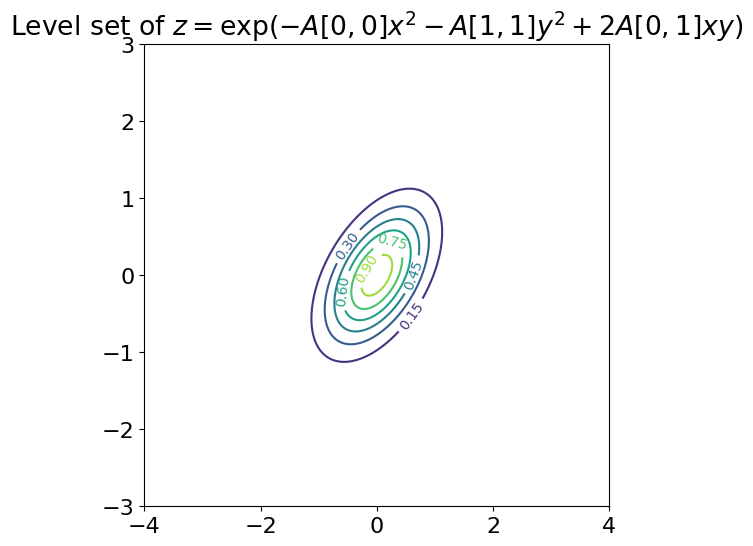

In [15]:
A = np.array([[2, 1],
            [1, 2]])

x = np.linspace(-4, 4, 1000)
y = np.linspace(-3, 3, 1000)

X, Y = np.meshgrid(x, y)
Z = np.exp(-A[0,0] *X**2 - A[1,1] * Y**2 + 2 * A[0,1 ] * X * Y)

plt.figure(1, figsize=(6, 6))

plt.title('Level set of $z  =  \exp( - A[0,0] x^2 - A[1,1] y^2 + 2 A[0,1] x y)$')
CS = plt.contour(X, Y, Z)
plt.clabel(CS, inline=True, fontsize=10)

<a list of 15 text.Text objects>

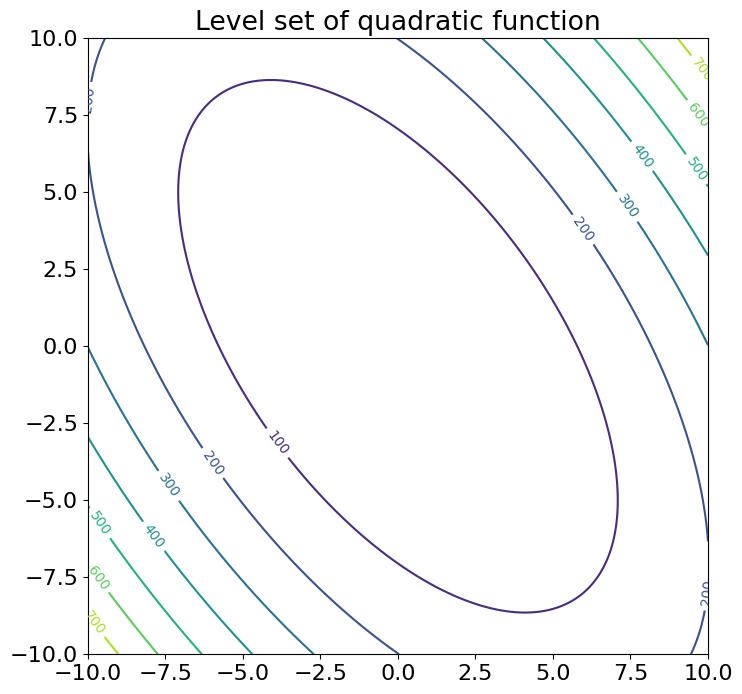

In [14]:
a = np.random.rand(2, 2)
q, r = np.linalg.qr(a) # q is a orthognoal matrix 
eig = np.diag([1, 4])

A = np.matmul(np.matmul(q, eig), q.T)

x = np.linspace(-10, 10, 1000)
y = np.linspace(-10, 10, 1000)

X, Y = np.meshgrid(x, y)
Z = A[0,0] *X**2 + A[1,1] * Y**2 - 2 * A[0,1 ] * X * Y

plt.figure(1, figsize=(8,8))

plt.title('Level set of quadratic function')
CS = plt.contour(X, Y, Z)
plt.clabel(CS, inline=True, fontsize=10)

<a list of 13 text.Text objects>

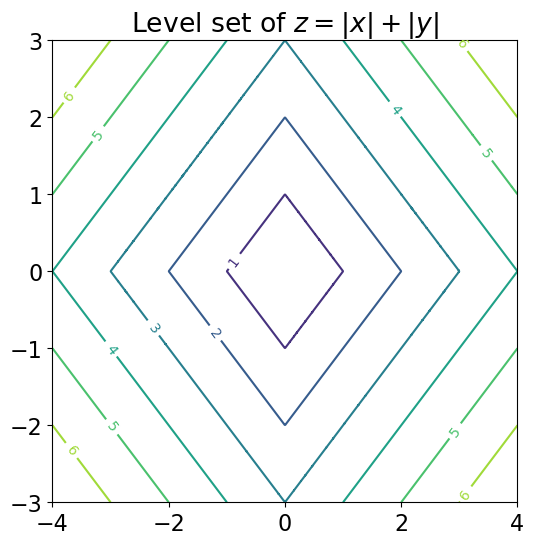

In [64]:

A = np.array([[2, 1],
            [1, 2]])

x = np.linspace(-4, 4, 1000)
y = np.linspace(-3, 3, 1000)

X, Y = np.meshgrid(x, y)
Z =  np.abs(X) +  np.abs(Y)

plt.figure(1, figsize=(6, 6))

plt.title('Level set of $z  =  |x| + |y|$')
CS = plt.contour(X, Y, Z)
plt.clabel(CS, inline=True, fontsize=10)

## First-Order Characterization of Convexity

If $f$ is differentiable, then $f$ is convex if and only if the **first-order condition** holds for all $x, y$ in the domain:

$$
f(y) \geq f(x) + \nabla f(x)^\top (y - x).
$$

In one dimension this reads $f(y) \geq f(x) + f'(x)(y - x)$: the tangent line at any point is a **global under-estimator** of the function. The plots below show the function (blue) and its first-order Taylor approximation at $x = 1$ (orange). Notice that the tangent line always lies below the curve.

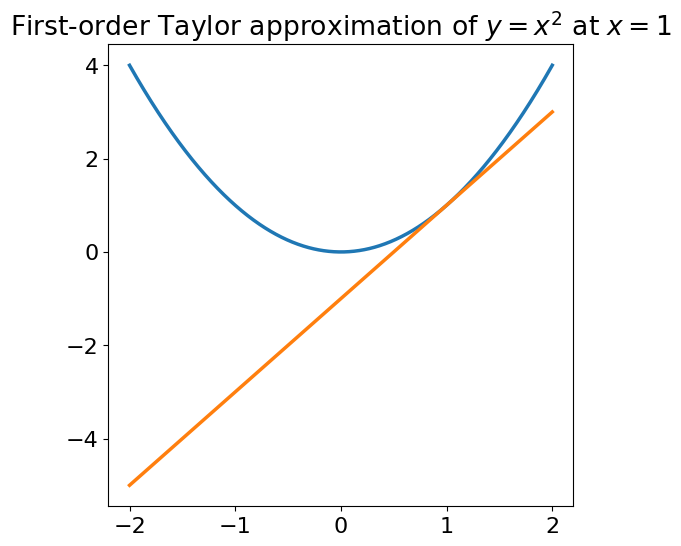

In [9]:

xs = np.linspace(-2, 2, 1000)
ys = xs**2

plt.figure(2, figsize=(6, 6))
plt.title('First-order Taylor approximation of $y = x^2$ at $x = 1$')

y1 = 1 + 2* (xs - 1)
plt.plot(xs, ys, **kwargs)
plt.plot(xs, y1, **kwargs)
# plt.savefig('taylor.pdf')

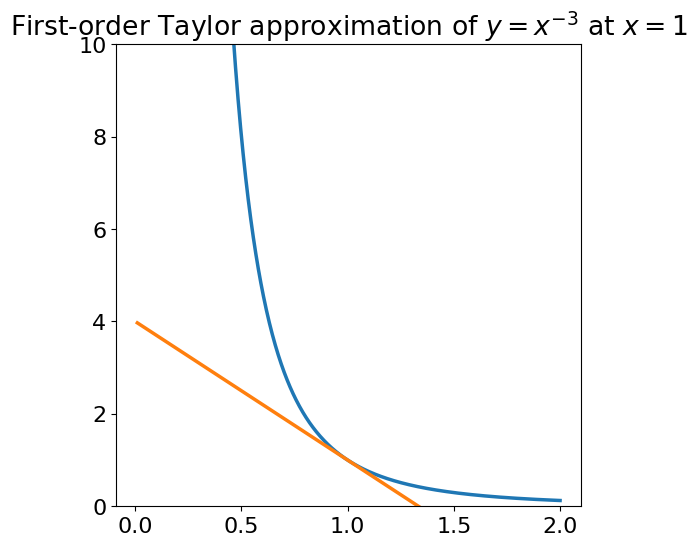

In [10]:

xs = np.linspace(0.01, 2, 1000)
ys = np.power(xs, -3)

plt.figure(2, figsize=(6, 6))
plt.title('First-order Taylor approximation of $y = x^{-3}$ at $x = 1$')

y1 = 1 + (-3)* (xs - 1)
plt.ylim(0, 10)
plt.plot(xs, ys, **kwargs)
plt.plot(xs, y1, **kwargs)
# plt.savefig('taylor.pdf')

## Summary

**Key takeaways from this notebook:**

1. **Epigraph characterization.** A function is convex if and only if its epigraph $\{(x,t) : t \geq f(x)\}$ is a convex set. Visually, the shaded region above the curve should have no "dents."

2. **Sublevel sets.** All sublevel sets of a convex function are convex. Contour plots of convex functions in $\mathbb{R}^2$ display nested convex curves (ellipses for quadratics, diamonds for the $\ell_1$-norm).

3. **First-order condition.** For differentiable $f$, convexity is equivalent to the tangent (hyper)plane being a global under-estimator: $f(y) \geq f(x) + \nabla f(x)^\top(y - x)$ for all $x, y$. This condition is the foundation for gradient-based optimality conditions in convex optimization.